# Airborne transmission - COVID-19

**Case study: UK COVID-19 first wave (spring 2020), real data.** An airborne, respiratory pathogen with a latent period and substantial asymptomatic transmission. This is the case where every intervention in the project is on the table, so we use it to show how **lockdown, vaccination and quarantine** each enter an epidemic model in a structurally different way: a time-varying contact rate (SIRD + lockdown), an extra compartment (SIRDV), and added latent/asymptomatic/isolation structure (SEAIQR). We then fit the models to the real reported UK curve and criticise how well they do.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd()
while not (_root / "simulation").exists() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from simulation import compartmental as cm
from simulation import grid, plotting, metrics
from simulation import interventions as itv
from simulation.grid import ABMParams, InterventionSettings, RandomWalkModel, run_ensemble
from simulation.agents import State

plotting.use_house_style()

## The reported first wave

Real data: Our World in Data, UK daily new confirmed cases per million (7-day rolling average).

peak: 2020-04-24 (day 54) at 70.5 per million


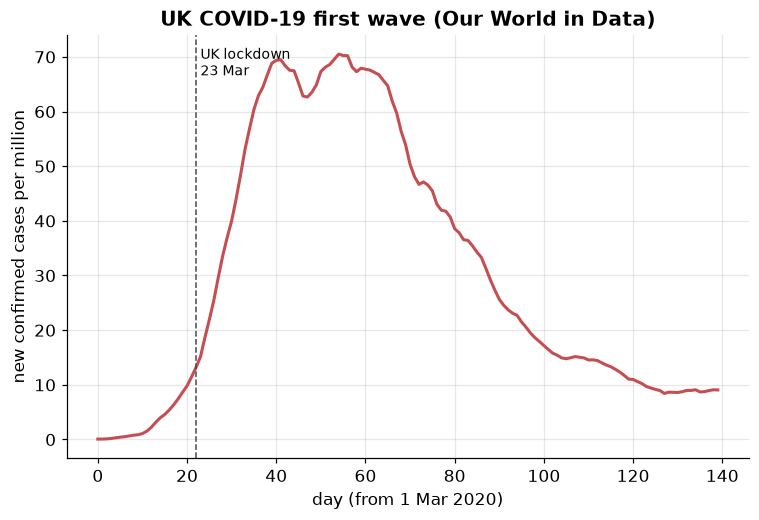

In [2]:
# Real data: Our World in Data, UK daily new confirmed cases per million,
# 7-day rolling average, 1 Mar - 18 Jul 2020 (the first wave).
DATA = pathlib.Path.cwd() / "data" / "owid_uk_daily_cases_per_million.csv"
raw = pd.read_csv(DATA)
raw["Day"] = pd.to_datetime(raw["Day"])
reported = pd.DataFrame({
    "day": (raw["Day"] - raw["Day"].min()).dt.days,   # days since 1 Mar 2020
    "date": raw["Day"],
    "cases_per_million": raw["New cases (per 1M)"],
})
LOCKDOWN_DAY = int((pd.Timestamp("2020-03-23") - raw["Day"].min()).days)   # UK lockdown

fig, ax = plt.subplots()
ax.plot(reported["day"], reported["cases_per_million"], color=plotting.PALETTE["I"], lw=2)
ax.axvline(LOCKDOWN_DAY, color=plotting.PALETTE["D"], ls="--", lw=1)
ax.text(LOCKDOWN_DAY + 1, ax.get_ylim()[1] * 0.9, "UK lockdown\n23 Mar", fontsize=9)
ax.set_xlabel("day (from 1 Mar 2020)"); ax.set_ylabel("new confirmed cases per million")
ax.set_title("UK COVID-19 first wave (Our World in Data)")
peak_day = int(reported.loc[reported["cases_per_million"].idxmax(), "day"])
print("peak:", reported.loc[reported["cases_per_million"].idxmax(), "date"].date(),
      f"(day {peak_day}) at {reported['cases_per_million'].max():.1f} per million")

## Baseline - SIRD with fatalities

Natural-history rates are from the COVID literature [5]; R0 = 2.5 is a representative first-wave value, consistent with the fit to the UK data later in the notebook.

In [3]:
# Population and natural-history parameters for the first wave.
# We work per million people (N = 1e6) so model counts line up directly with the
# OWID "cases per million" series.
N   = 1_000_000
I0  = 50
gamma = 1 / 6.0            # ~6 day infectious period
sigma = 1 / 5.1           # incubation rate, ~5.1 day latent period [5]
DAYS  = 220

cfr = 0.007               # infection fatality ratio ~0.7%
mu  = cfr * gamma / (1 - cfr)
R0  = 2.5                 # first-wave R0 (consistent with the UK fit below)
beta = R0 * (gamma + mu)  # SIRD contact rate giving that R0

SIRD R0 = 2.50
unmitigated peak infectious = 233,501 on day 41
cumulative deaths = 6,249  (0.6% of population)


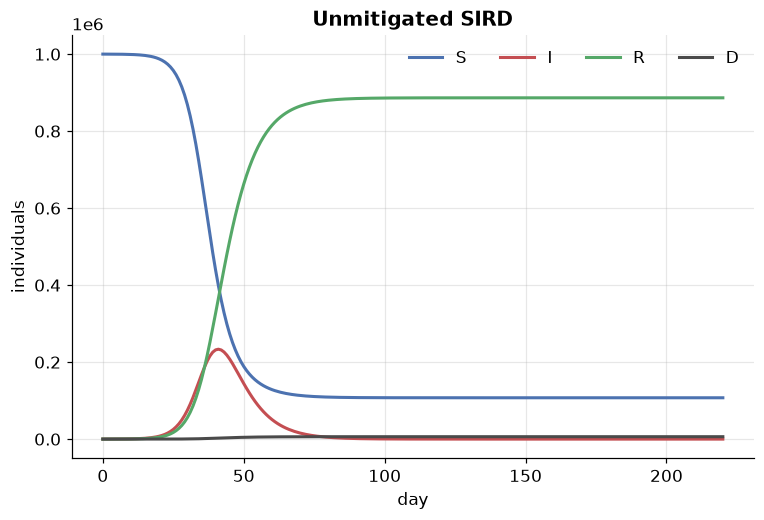

In [4]:
sird = cm.SIRD(cm.SIRDParams(beta, gamma, mu), N)
base = sird.simulate([N - I0, I0, 0, 0], DAYS, DAYS + 1)
print(f"SIRD R0 = {sird.r0():.2f}")
print(f"unmitigated peak infectious = {base['I'].max():,.0f} on day {base['I'].idxmax():.0f}")
print(f"cumulative deaths = {base['D'].iloc[-1]:,.0f}  ({base['D'].iloc[-1]/N:.1%} of population)")

fig, ax = plt.subplots()
plotting.plot_compartments(base, ["S", "I", "R", "D"], ax=ax, title="Unmitigated SIRD")
ax.set_xlabel("day");

## Intervention 1 - lockdown (a time-varying contact rate)

Lockdown is not a new compartment: it is a temporary cut in the contact rate,
so it plugs straight into the model through the `contact_scaling` hook [6]. The
timing matters - a lockdown that starts after the peak does almost nothing.

no lockdown            peak I =  233,501 on day  41   deaths =  6,249
temporary (60 days)    peak I =  176,067 on day 107   deaths =  6,079
sustained              peak I =   12,288 on day  22   deaths =  1,038


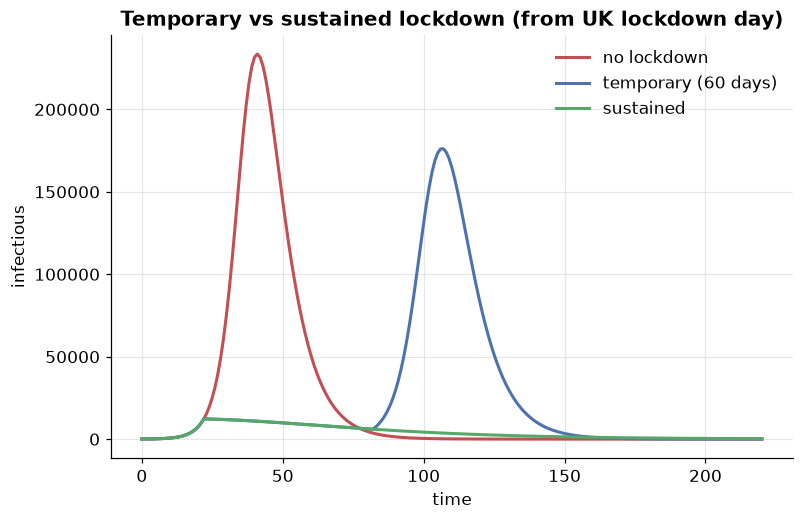

In [5]:
# Anchored on the real UK lockdown (day 22). A temporary lockdown only delays
# the peak; a sustained one suppresses it.
scenarios = {"no lockdown": base}
for tag, end in [("temporary (60 days)", LOCKDOWN_DAY + 60), ("sustained", None)]:
    m = cm.SIRD(cm.SIRDParams(beta, gamma, mu), N)
    itv.Lockdown(start=LOCKDOWN_DAY, end=end, strength=0.6).apply_to(m)
    scenarios[tag] = m.simulate([N - I0, I0, 0, 0], DAYS, DAYS + 1)

curves = {name: (df.index, df["I"]) for name, df in scenarios.items()}
plotting.plot_scenarios(curves, title="Temporary vs sustained lockdown (from UK lockdown day)",
                        ylabel="infectious")
for name, df in scenarios.items():
    print(f"{name:22s} peak I = {df['I'].max():8,.0f} on day {df['I'].idxmax():3.0f}   "
          f"deaths = {df['D'].iloc[-1]:6,.0f}")

## Intervention 2 - vaccination (a structural change)

Vaccination *does* need its own compartment, because vaccinated people are a
distinct group who can still be infected but at a reduced rate. That is the
SIRDV model. Here a rolling campaign starts alongside the outbreak.

no vaccine             deaths =   6,249   final susceptible =  107,348
vaccinate 0.5%/day     deaths =   5,168   final susceptible =   52,559
vaccinate 2.0%/day     deaths =   1,271   final susceptible =    7,796


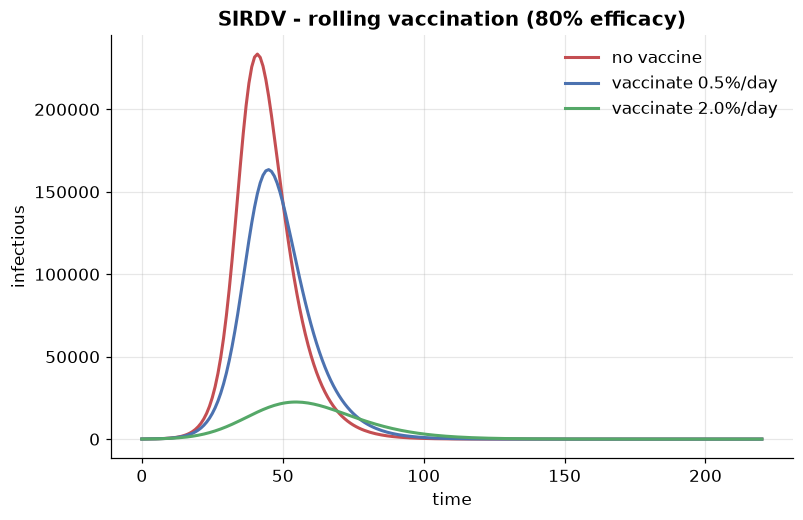

In [6]:
vax_scenarios = {"no vaccine": base}
for nu in [0.005, 0.02]:
    m = cm.SIRDV(cm.SIRDVParams(beta, gamma, mu, nu=nu, efficacy=0.8), N)
    out = m.simulate([N - I0, 0, I0, 0, 0], DAYS, DAYS + 1)
    vax_scenarios[f"vaccinate {nu:.1%}/day"] = out

curves = {name: (df.index, df["I"]) for name, df in vax_scenarios.items()}
plotting.plot_scenarios(curves, title="SIRDV - rolling vaccination (80% efficacy)",
                        ylabel="infectious")
for name, df in vax_scenarios.items():
    print(f"{name:22s} deaths = {df['D'].iloc[-1]:7,.0f}   "
          f"final susceptible = {df['S'].iloc[-1]:8,.0f}")

## Intervention 3 - quarantine (isolating detected cases)

Quarantine needs the extra structure of a latent (exposed) period and a silent
asymptomatic route to be meaningful, so we switch to the SEAIQR model.
Increasing the isolation rate `q` pulls the reproduction number down directly.

isolation rate q = 0.0   ->  R0 = 2.50   peak infectious =   74,511
isolation rate q = 0.15  ->  R0 = 1.61   peak infectious =   16,971
isolation rate q = 0.4   ->  R0 = 1.18   peak infectious =      891


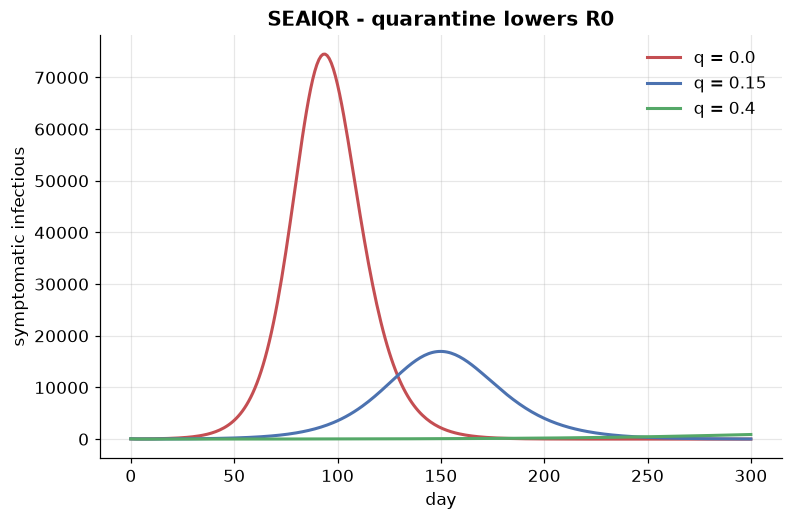

In [7]:
rho, eta = 0.6, 0.5                      # 60% symptomatic; asymptomatics half as infectious
beta_se = R0 * gamma / (eta * (1 - rho) + rho)   # gives R0 = 2.5 at q = 0

q_scenarios = {}
for q in [0.0, 0.15, 0.4]:
    m = cm.SEAIQR(cm.SEAIQRParams(beta_se, sigma, gamma, rho=rho, eta=eta, q=q), N)
    out = m.simulate([N - I0, 0, 0, I0, 0, 0], 300, 301)
    q_scenarios[f"q = {q}"] = out
    print(f"isolation rate q = {q:<4}  ->  R0 = {m.r0():.2f}   "
          f"peak infectious = {out['I'].max():8,.0f}")

curves = {name: (df.index, df["I"]) for name, df in q_scenarios.items()}
plotting.plot_scenarios(curves, title="SEAIQR - quarantine lowers R0",
                        ylabel="symptomatic infectious")
plt.gca().set_xlabel("day");

## Agent-based airborne spread

For an airborne disease the agent rule is proximity: a susceptible can be
infected by any infectious agent within a short radius, not only one sharing its
cell. The three interventions map onto the agents directly - lockdown reduces
movement, vaccination immunises a fraction up front, and quarantine makes
detected cases stop moving.

baseline         peak infectious = 357


lockdown         peak infectious = 236
vaccinate 50%    peak infectious = 46


quarantine 60%   peak infectious = 298


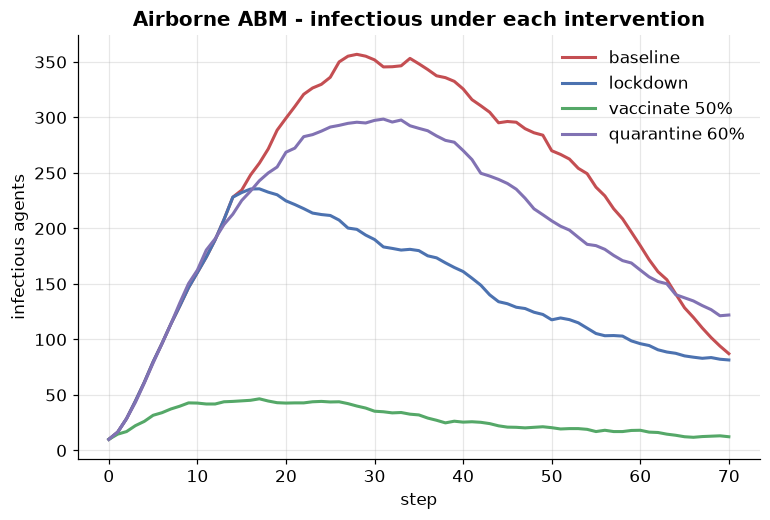

In [8]:
abm_params = ABMParams(infect_prob=0.18, radius=2.0, recovery_prob=0.12, step_prob=0.85)
GRID, NAG, STEPS, RUNS = 80, 2500, 70, 6
common = dict(grid_size=GRID, n_agents=NAG, mechanism="airborne",
              params=abm_params, n_infected=10, base_seed=100)

interventions = {
    "baseline":        None,
    "lockdown":        InterventionSettings(lockdown_start=15, lockdown_step_prob=0.1),
    "vaccinate 50%":   InterventionSettings(vaccinated_fraction=0.5),
    "quarantine 60%":  InterventionSettings(quarantine_fraction=0.6, quarantine_delay=3),
}
abm_curves = {}
for name, iv in interventions.items():
    mean, _ = run_ensemble(RUNS, STEPS, interventions=iv, **common)
    abm_curves[name] = (np.arange(mean.shape[0]), mean[:, State.INFECTIOUS])
    print(f"{name:16s} peak infectious = {mean[:, State.INFECTIOUS].max():.0f}")

plotting.plot_scenarios(abm_curves, title="Airborne ABM - infectious under each intervention",
                        ylabel="infectious agents")
plt.gca().set_xlabel("step");

In [ ]:
# A single baseline replicate frozen early and near the peak.
model = RandomWalkModel(GRID, NAG, "airborne", abm_params, n_infected=10, seed=100)
frames = list(model.run(STEPS))
early, mid = frames[10], frames[np.argmax([f.counts[State.INFECTIOUS] for f in frames])]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 5.4))
plotting.plot_grid_snapshot(early.population, GRID, ax=a1, title=f"step {early.t}",
                            legend=False)
plotting.plot_grid_snapshot(mid.population, GRID, ax=a2, title=f"step {mid.t} (peak)",
                            legend=False)

# One key for both panels, below the grids, so it never sits on top of the agents.
keys = {}
for ax in (a1, a2):
    for handle, label in zip(*ax.get_legend_handles_labels()):
        keys.setdefault(label, handle)
fig.legend(keys.values(), keys.keys(), loc="lower center", ncol=len(keys),
           markerscale=2.0, fontsize=9, frameon=False, bbox_to_anchor=(0.5, 0.01))
fig.tight_layout(rect=(0, 0.07, 1, 1));

## Validation against the real UK first wave

Now the honest test: fit the models to the OWID data and see how well - and how
badly - they do. We try two things and criticise both:

1. an **unmitigated SIRD** (scan R0, best reporting fraction), and
2. an **SIRD with the real UK lockdown** on day 22 (scan R0 and lockdown
   strength).

The comparison is the point: how much structure does the model need before it
resembles reality, and what can the fit *not* tell us?

unmitigated SIRD:   R0 = 1.95, R^2 = 0.389, attack rate = 0.78
SIRD + UK lockdown: R0 = 2.50, contact cut = 45%, R^2 = 0.930, attack rate = 0.51
model peak day = 56, data peak day = 54


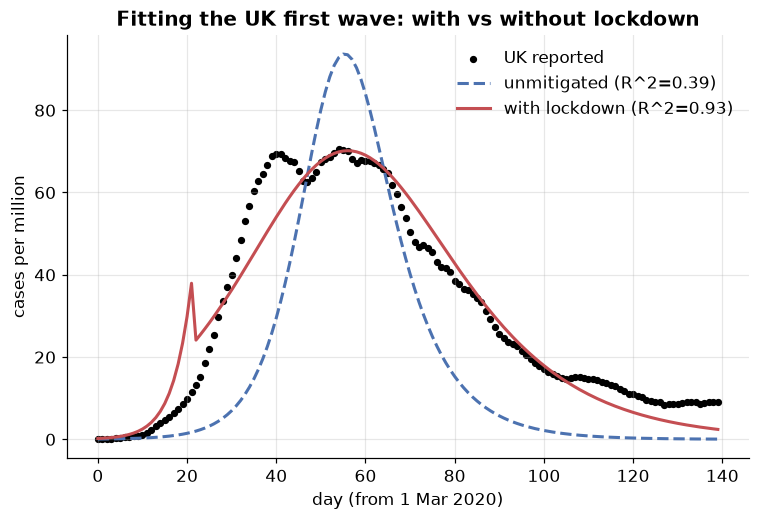

In [10]:
obs = reported["cases_per_million"].values          # N = 1e6, so counts line up
days = reported["day"].values

def score(inc):
    inc = inc[: len(obs)]
    scale = np.sum(inc * obs) / np.sum(inc ** 2)     # least-squares reporting fraction
    fitted = inc * scale
    r2 = 1 - np.sum((fitted - obs) ** 2) / np.sum((obs - obs.mean()) ** 2)
    return fitted, scale, r2

# 1) unmitigated SIRD
best_u = None
for R0_try in np.round(np.arange(1.4, 3.01, 0.05), 2):
    d = cm.SIRD(cm.SIRDParams(R0_try * (gamma + mu), gamma, mu), N).simulate(
        [N - I0, I0, 0, 0], DAYS, DAYS + 1)
    f, s, r2 = score(-np.diff(d["S"].values))
    if best_u is None or r2 > best_u[3]:
        best_u = (R0_try, f, s, r2, d)

# 2) SIRD + real UK lockdown (fit R0 and strength)
best_l = None
for R0_try in np.round(np.arange(2.0, 4.01, 0.1), 2):
    for strength in np.round(np.arange(0.35, 0.81, 0.05), 2):
        m = cm.SIRD(cm.SIRDParams(R0_try * (gamma + mu), gamma, mu), N)
        itv.Lockdown(start=LOCKDOWN_DAY, end=None, strength=strength).apply_to(m)
        d = m.simulate([N - I0, I0, 0, 0], DAYS, DAYS + 1)
        f, s, r2 = score(-np.diff(d["S"].values))
        if best_l is None or r2 > best_l[4]:
            best_l = (R0_try, strength, f, s, r2, d)

print(f"unmitigated SIRD:   R0 = {best_u[0]:.2f}, R^2 = {best_u[3]:.3f}, "
      f"attack rate = {1 - best_u[4]['S'].iloc[-1] / N:.2f}")
print(f"SIRD + UK lockdown: R0 = {best_l[0]:.2f}, contact cut = {best_l[1]:.0%}, "
      f"R^2 = {best_l[4]:.3f}, attack rate = {1 - best_l[5]['S'].iloc[-1] / N:.2f}")
print(f"model peak day = {int(best_l[2].argmax())}, data peak day = {int(obs.argmax())}")

fig, ax = plt.subplots()
ax.scatter(days, obs, color=plotting.PALETTE["data"], s=14, label="UK reported")
ax.plot(days[: len(best_u[1])], best_u[1], color=plotting.PALETTE["S"], lw=2, ls="--",
        label=f"unmitigated (R^2={best_u[3]:.2f})")
ax.plot(days[: len(best_l[2])], best_l[2], color=plotting.PALETTE["I"], lw=2,
        label=f"with lockdown (R^2={best_l[4]:.2f})")
ax.set_xlabel("day (from 1 Mar 2020)"); ax.set_ylabel("cases per million")
ax.set_title("Fitting the UK first wave: with vs without lockdown")
ax.legend();

**Criticising the fit.** The unmitigated SIRD fits the real wave poorly (R^2 ~ 0.4): with no intervention it grows too fast and overshoots the observed peak. Adding the *real* UK lockdown date and fitting one contact-reduction number lifts the fit to R^2 ~ 0.9 and puts the peak within a couple of days of 24 April - strong evidence that the shape of the first wave was set by the lockdown, not by the virus alone.

But two things the fit **cannot** be trusted on, both rooted in the data:

- The series is a **7-day rolling average of *confirmed* cases**, and early testing was severely limited, so it is a smoothed *undercount* of true infections. The fitted reporting fraction is therefore not a clean ascertainment rate.
- Because confirmed cases undercount infections, the model's fitted **attack rate (~50%) is far above the ~6-7% first-wave seroprevalence** later estimated for the UK. We are fitting the *shape and timing* of reported dynamics, which is all a reported-case curve can honestly validate - not the absolute number infected.

## Summary

In [11]:
rows = {
    "no intervention": metrics.summarise(base["S"], base["I"], base["R"], N,
                                         deaths=base["D"], times=base.index),
}
lock = scenarios["sustained"]
rows["sustained lockdown"] = metrics.summarise(lock["S"], lock["I"], lock["R"], N,
                                               deaths=lock["D"], times=lock.index)
vac = vax_scenarios["vaccinate 2.0%/day"]
rows["vaccination"] = metrics.summarise(vac["S"], vac["I"], vac["R"], N,
                                        deaths=vac["D"], times=vac.index)
metrics.comparison_table(rows).round(2)

,peak_value,peak_time,attack_rate,final_size
no intervention,233500.82,41.0,0.89,892652.09
sustained lockdown,12288.13,22.0,0.15,148262.73
vaccination,22486.60,55.0,0.99,181632.68


**Read-out.** The three interventions act through genuinely different mechanisms. Lockdown is a contact cut - a temporary one flattens and delays the peak but the epidemic rebounds on release, a sustained one suppresses it. Vaccination removes susceptibles permanently and, once fast enough, prevents the wave outright. Quarantine works on the reproduction number itself and is the only one that can push R0 below 1 without confining the whole population - but it needs the SEAIQR structure (latent + asymptomatic) to be modelled honestly, since undetected asymptomatic spread sets a floor on how well isolation can do. Fitted to the real UK data, the model only resembles the first wave once the actual lockdown is included (R^2 jumps from poor to ~0.9), which is the clearest possible demonstration that the intervention - not the virus alone - shaped the epidemic.

*Limitations.* Constant R0 between interventions (no behavioural feedback or variants); homogeneous mixing in the ODEs; a leaky-but-simple vaccine model; and, in the data, a 7-day-averaged confirmed-case series that undercounts true infections (see `data/README.md`), so the fit is honest about *timing and shape* but not absolute magnitude.